analysis -> feature eng -> model -> web app

In [2355]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns


In [2356]:
pd.set_option("display.max_columns", None)

In [2357]:
sns.set_style("whitegrid")

In [2358]:
df = pd.read_csv("german_credit_data.csv")

In [2359]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [2360]:
df["Age"].describe()

count    1000.000000
mean       35.546000
std        11.375469
min        19.000000
25%        27.000000
50%        33.000000
75%        42.000000
max        75.000000
Name: Age, dtype: float64

In [2361]:
df["Risk"].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [2362]:
df.shape

(1000, 11)

In [2363]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [2364]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1000.0,NaN,NaN,NaN,499.5,288.819436,0.0,249.75,499.5,749.25,999.0
Age,1000.0,NaN,NaN,NaN,35.546,11.375469,19.0,27.0,33.0,42.0,75.0
Sex,1000,2,male,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,1000.0,NaN,NaN,NaN,1.904,0.653614,0.0,2.0,2.0,2.0,3.0
Housing,1000,3,own,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,817,4,little,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,606,3,little,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
Purpose,1000,8,car,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2365]:
df["Job"].unique()

array([2, 1, 3, 0])

In [2366]:
df.isna().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [2367]:
df.duplicated().sum()

np.int64(0)

In [2368]:
df.dropna().reset_index(drop=True)

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,4,53,male,2,free,little,little,4870,24,car,bad
3,7,35,male,3,rent,little,moderate,6948,36,car,good
4,9,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
517,989,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,993,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,996,40,male,3,own,little,little,3857,30,car,good
520,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [2369]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [2370]:
df.drop(columns='Unnamed: 0', inplace=True)

In [2371]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

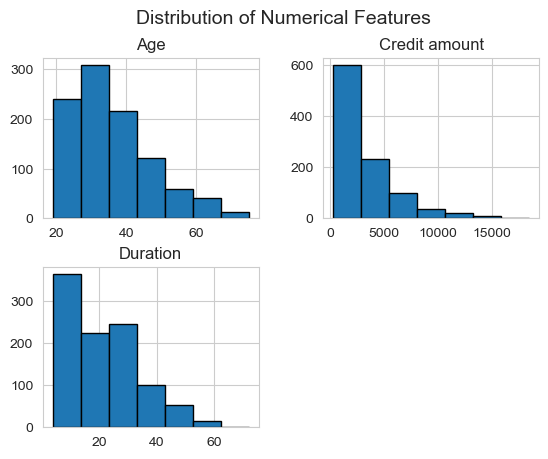

In [2372]:
df[["Age", "Credit amount", "Duration"]].hist(bins=7, edgecolor = "black")
plt.suptitle("Distribution of Numerical Features", fontsize = 14)
plt.show()

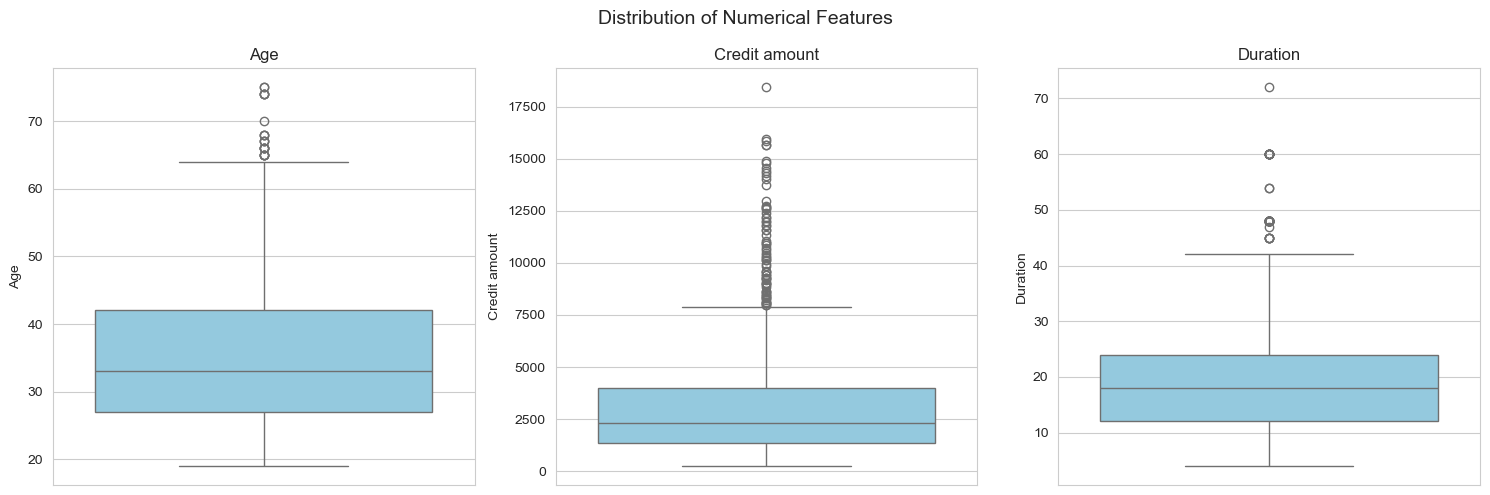

In [2373]:
plt.figure(figsize=(15, 5))
for i, col in enumerate(["Age", "Credit amount", "Duration"]):
    plt.subplot(1, 3, i + 1)  
    sns.boxplot(y=df[col], color="skyblue")
    plt.title(col)
plt.suptitle("Distribution of Numerical Features", fontsize=14)  # Main title for all subplots
plt.tight_layout()
plt.show()

In [2374]:
df.query("Duration >= 60")

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/displayhook.py:292: UserWarning: Output cache limit (currently 1000 entries) hit.
Flushing oldest 200 entries.
  warn('Output cache limit (currently {sz} entries) hit.\n'


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
29,63,male,2,own,little,little,6836,60,business,bad
134,21,female,2,own,moderate,NaN,10144,60,radio/TV,good
255,27,male,1,own,NaN,moderate,7418,60,radio/TV,good
332,24,female,3,own,moderate,moderate,7408,60,car,bad
373,63,male,3,free,NaN,NaN,13756,60,car,good
374,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
616,27,male,3,free,NaN,moderate,9157,60,radio/TV,good
637,21,male,2,own,little,NaN,15653,60,radio/TV,good
672,42,male,3,own,little,NaN,10366,60,car,good
677,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad


In [2375]:
categorical_cols = ["Sex", "Job","Housing","Saving accounts","Checking account","Purpose"]

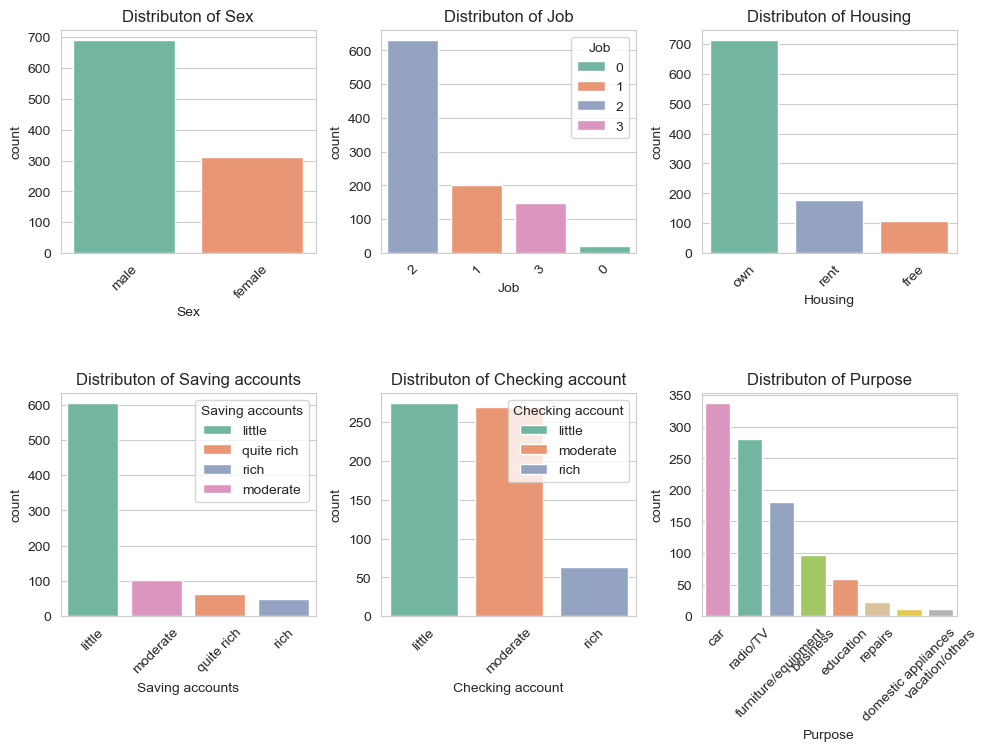

In [2376]:
plt.figure(figsize= (10,10))
for i , col in enumerate(categorical_cols):
    plt.subplot(3, 3, i+1)
    sns.countplot(data= df, x = col, hue=col, palette= "Set2", order = df[col].value_counts().index )
    plt.title(f"Distributon of {col}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [2377]:
corr = df[["Age", "Job", "Credit amount", "Duration"]].corr()

In [2378]:
corr

,Age,Job,Credit amount,Duration
Age,1.000000,0.015673,0.032716,-0.036136
Job,0.015673,1.000000,0.285385,0.210910
Credit amount,0.032716,0.285385,1.000000,0.624984
Duration,-0.036136,0.210910,0.624984,1.000000


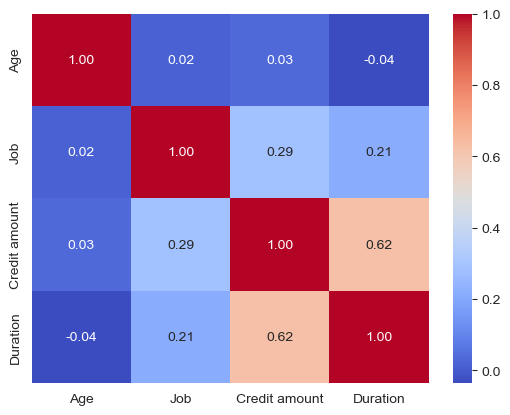

In [2379]:
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

In [2380]:
df.groupby("Job")["Credit amount"].mean()

Job
0    2745.136364
1    2358.520000
2    3070.965079
3    5435.493243
Name: Credit amount, dtype: float64

In [2381]:
df.groupby("Sex")["Credit amount"].mean()

Sex
female    2877.774194
male      3448.040580
Name: Credit amount, dtype: float64

In [2382]:
pd.pivot_table(df, values="Credit amount", index="Housing", columns="Purpose")

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4931.800000,5834.181818,NaN,4387.266667,4100.181818,2417.333333,2750.666667,7227.250
own,3800.592105,3329.949772,1546.5,2198.647059,3107.459016,2540.493392,2866.000000,8700.375
rent,5614.125000,3487.968254,1255.5,2931.000000,2727.354167,2199.763158,1522.000000,NaN


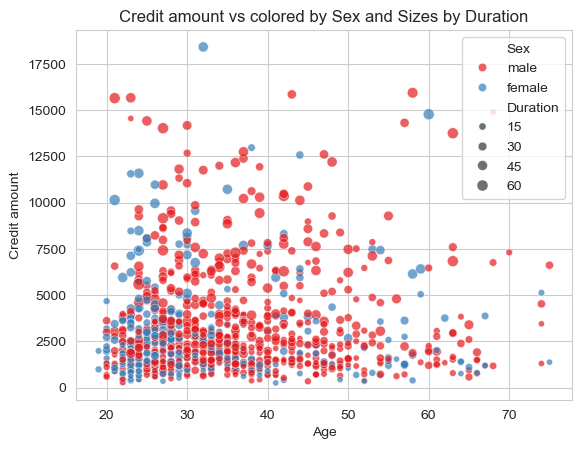

In [2383]:
sns.scatterplot(data = df, x = "Age", y="Credit amount", hue="Sex", size="Duration", alpha=0.7, palette="Set1")
plt.title("Credit amount vs colored by Sex and Sizes by Duration")
plt.show()

/var/folders/9z/vvzcv_wj0g39tjrdjn9tlypr0000gn/T/ipykernel_2903/130658189.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Saving accounts", y="Credit amount", palette="Set2")


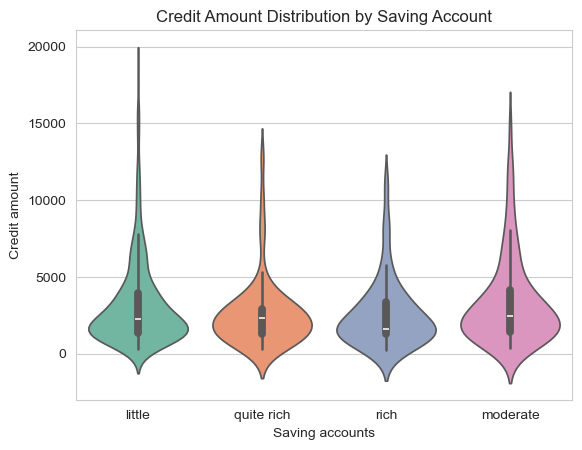

In [2384]:
# This ALWAYS works
sns.violinplot(data=df, x="Saving accounts", y="Credit amount", palette="Set2")
plt.title("Credit Amount Distribution by Saving Account")
plt.show()

In [2385]:
df["Risk"].value_counts(normalize=True)* 100

Risk
good    70.0
bad     30.0
Name: proportion, dtype: float64

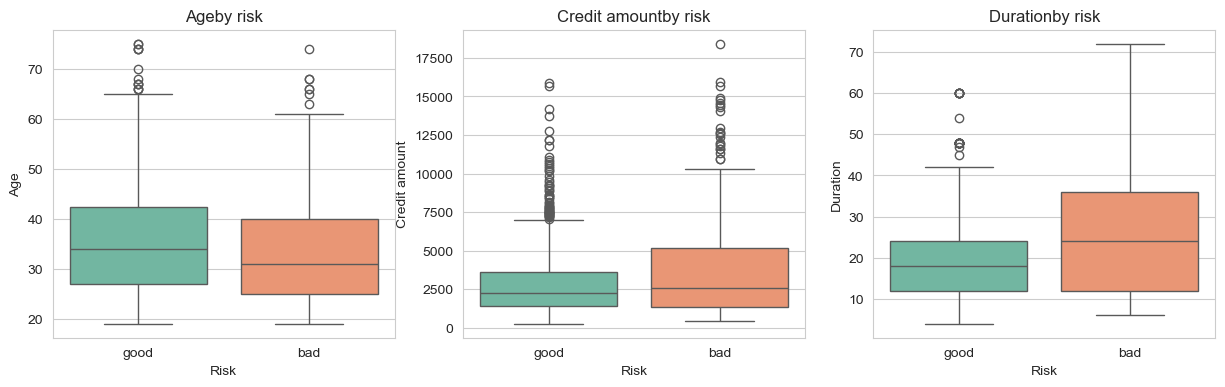

In [2386]:
plt.figure(figsize=(15,4))
for i, col in enumerate(["Age", "Credit amount", "Duration"]):
    plt.subplot(1, 3, i+1)
    sns.boxplot(data= df, x="Risk", y=col, hue="Risk", palette="Set2", legend=False)
    plt.title(f"{col}by risk")

plt.tight_layout
plt.show()

In [2387]:
df.groupby("Risk")[["Age", "Credit amount", "Duration"]].mean()

,Age,Credit amount,Duration
Risk,,,
bad,33.963333,3938.126667,24.860000
good,36.224286,2985.457143,19.207143


In [2388]:
categorical_cols

['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

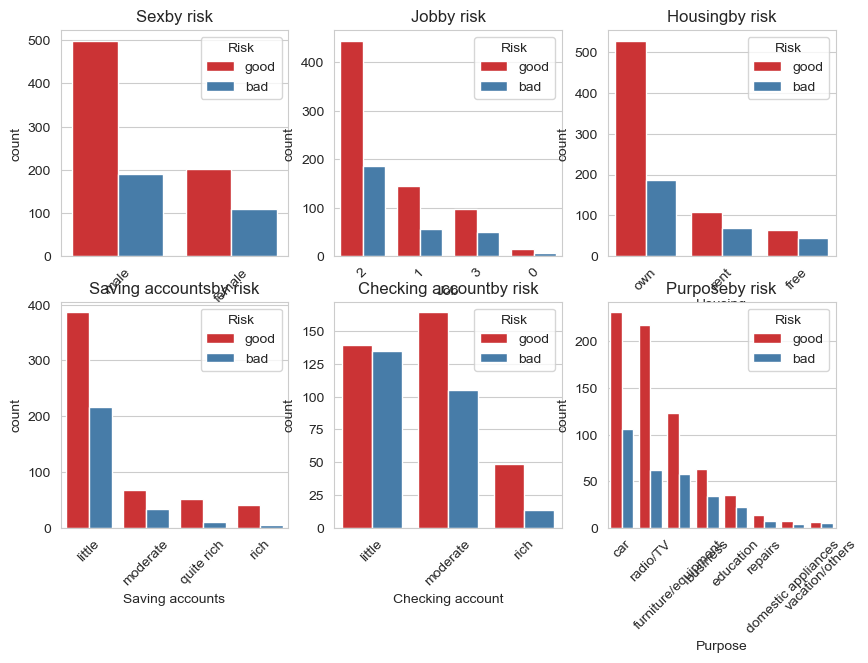

In [2389]:
plt.figure(figsize=(10,10))
for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i+1)
    sns.countplot(data= df, x=col, hue="Risk", palette="Set1", order=df[col].value_counts().index)
    plt.title(f"{col}by risk")
    plt.xticks(rotation= 45)

plt.tight_layout
plt.show()

In [2390]:
features = ["Age", "Sex", "Job", "Housing", "Saving accounts", "Checking account", "Duration" ]

In [2391]:
target = "Risk"

In [2392]:
df_model = df[features + [target]].copy()

In [2393]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Duration,Risk
0,67,male,2,own,NaN,little,6,good
1,22,female,2,own,little,moderate,48,bad
2,49,male,1,own,little,NaN,12,good
3,45,male,2,free,little,little,42,good
4,53,male,2,free,little,little,24,bad


In [2394]:
from sklearn.preprocessing import LabelEncoder
import joblib

In [2395]:
cat_cols = df_model.select_dtypes(include="object").columns.drop("Risk")

In [2396]:
le_dict = {}

In [2397]:
cat_cols

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account'], dtype='object')

In [2398]:
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] = le
    joblib.dump(le, f"{col}_encoder.pkl")

In [2399]:
le_target = LabelEncoder()

In [2400]:
target

'Risk'

In [2401]:
df_model[target] = le_target.fit_transform(df_model[target])

In [2402]:
df_model[target]

0      1
1      0
2      1
3      1
4      0
      ..
995    1
996    1
997    1
998    0
999    1
Name: Risk, Length: 1000, dtype: int64

In [2403]:
df_model[target].value_counts()

Risk
1    700
0    300
Name: count, dtype: int64

In [2404]:
 
joblib.dump(le_target, "target_encoder.pkl")

['target_encoder.pkl']

In [2405]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Duration,Risk
0,67,1,2,1,4,0,6,1
1,22,0,2,1,0,1,48,0
2,49,1,1,1,0,3,12,1
3,45,1,2,0,0,0,42,1
4,53,1,2,0,0,0,24,0


In [2406]:
from sklearn.model_selection import train_test_split

In [2407]:
x = df_model.drop(target, axis = 1) 

In [2408]:
y = df_model[target]

In [2409]:
x

,Age,Sex,Job,Housing,Saving accounts,Checking account,Duration
0,67,1,2,1,4,0,6
1,22,0,2,1,0,1,48
2,49,1,1,1,0,3,12
3,45,1,2,0,0,0,42
4,53,1,2,0,0,0,24
...,...,...,...,...,...,...,...
995,31,0,1,1,0,3,12
996,40,1,3,1,0,0,30
997,38,1,2,1,0,3,12
998,23,1,2,0,0,0,45


In [2410]:
y   

0      1
1      0
2      1
3      1
4      0
      ..
995    1
996    1
997    1
998    0
999    1
Name: Risk, Length: 1000, dtype: int64

In [2411]:
target

'Risk'

In [2412]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, stratify=y, random_state=1 )

In [2413]:
x_train.shape

(800, 7)

In [2414]:
x_test.shape 

(200, 7)

In [2415]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
import sys
!{sys.executable} -m pip install xgboost
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
import streamlit as model
import pandas as pd 
import joblib



print("✅ All imports successful!")

✅ All imports successful!


In [2416]:
def train_model(model, param_grid, x_train, y_train, x_test, y_test):
    grid = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
    grid.fit(x_train, y_train)
    best_model = grid.best_estimator_
    accuracy = grid.score(x_test, y_test)
    return best_model, accuracy, grid.best_params_


In [2417]:
dt = DecisionTreeClassifier(random_state=1, class_weight="balanced")
dt_params_grid = {
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [2418]:
best_dt, acc_dt, params_dt = train_model(dt, dt_params_grid, x_train, y_train, x_test, y_test)

In [2419]:
print(f"Decision Tree Accuracy: {acc_dt:.4f}")


Decision Tree Accuracy: 0.6850


In [2420]:
print(f"Best Parameters: {params_dt}")

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [2421]:
rf = RandomForestClassifier(random_state=1, class_weight="balanced", n_jobs=-1)

In [2422]:
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 7, 10, None],
    "min_samples_split": [2, 5, 10],      
    "min_samples_leaf": [1, 2, 4]         
}

In [2423]:
best_rf, acc_rf, params_rf = train_model(rf, rf_param_grid, x_train, y_train, x_test, y_test)

In [2424]:
print("Random Forest Accuracy", acc_rf)

Random Forest Accuracy 0.75


In [2425]:
print(f"Best Parameters: {params_rf}")

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [2426]:
et = ExtraTreesClassifier(random_state=1, class_weight="balanced", n_jobs=-1)

In [2427]:
et_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 7, 10, None],
    "min_samples_split": [2, 5, 10],      
    "min_samples_leaf": [1, 2, 4]         
}

In [2428]:
best_et, acc_et, params_et = train_model(et, et_param_grid, x_train, y_train, x_test, y_test)

In [2429]:
print("Extra tress Accuracy", acc_et)

Extra tress Accuracy 0.74


In [2430]:
print(f"Best Parameters: {params_et}")

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


In [2431]:
xgb = XGBClassifier(random_state=1,scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),use_label_encoder=False,eval_metric="logloss"
)

In [2432]:
xgb_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample" : [0.7, 7, 1 ]
}

In [2433]:
print(f" XGBoost Accuracy: {acc_xgb")

SyntaxError: f-string: expecting '}' (2180832717.py, line 1)

In [ ]:
print(f" Best Parameters: {params_xgb}")

In [ ]:
import streamlit as st
import pandas as pd
import joblib

# Load model and encoders
model = joblib.load("extra_trees_credit_model.pkl")
encoders = {col: joblib.load(f"{col}_encoder.pkl") for col in ['Sex', 'Housing', 'Saving accounts', 'Purpose']}

st.title("Credit Risk Prediction App")
st.write("Enter applicant information to predict if the credit risk is good")

# Input fields
age = st.number_input("Age", min_value=18, max_value=80, value=30)
sex = st.selectbox("Sex", ["male", "female"])
job = st.number_input("Job (0-3)", min_value=0, max_value=3, value=1)
housing = st.selectbox("Housing", ["own", "rent", "free"])
saving_accounts = st.selectbox("Saving Accounts", ["little", "moderate", "rich", "quite rich"])
purpose = st.selectbox("Purpose", ["car", "furniture", "education", "business"])
credit_amount = st.number_input("Credit Amount", min_value=0, value=1000)
duration = st.number_input("Duration (months)", min_value=1, value=12)

# Create input DataFrame
input_df = pd.DataFrame({
    "Age": [age],
    "Sex": [sex],
    "Job": [job],
    "Housing": [housing],
    "Saving accounts": [saving_accounts],
    "Purpose": [purpose],
    "Credit amount": [credit_amount],
    "Duration": [duration]
})

# Encode categorical columns
for col in ['Sex', 'Housing', 'Saving accounts', 'Purpose']:
    if col in encoders:
        input_df[col] = encoders[col].transform(input_df[col])

# Predict
if st.button("Predict Credit Risk"):
    prediction = model.predict(input_df)
    risk = "Good" if prediction[0] == 1 else "Bad"
    st.subheader(f"Credit Risk: {risk}")